In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
from pathlib import Path

# Tạo thư mục làm việc trên Drive
WORK_DIR = Path("/content/drive/MyDrive/Lab02_HousePrice")
WORK_DIR.mkdir(parents=True, exist_ok=True)

# Chuyển vào thư mục đó
os.chdir(WORK_DIR)
print("Đang làm việc tại:", os.getcwd())

Đang làm việc tại: /content/drive/MyDrive/Lab02_HousePrice


# Model 2: Decision Tree — House Prices

Notebook tinh chỉnh siêu tham số **Decision Tree** (scikit-learn) cho bài House Prices.

Kết quả được lưu đúng format:

```
experiments/decision_tree/<timestamp>/
├── config.json
├── metrics.json
├── model.pkl
├── predictions.csv
└── top10_configs.csv
```


## 1. Import

In [5]:
import os
import json
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
np.random.seed(42)
print("sklearn / pandas OK")

sklearn / pandas OK


## 2. Load dữ liệu


In [6]:
DATA = Path("Data")

train_df = pd.read_csv(DATA/"train.csv")
test_df  = pd.read_csv(DATA/ "test.csv")
sample_sub = pd.read_csv(DATA / "sample_submission.csv")

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (1460, 81)
Test : (1459, 80)


## 3. Preprocessing

Fill missing + one-hot, giữ train/test cùng số cột.

In [7]:
y = train_df["SalePrice"].copy()
train_feat = train_df.drop(columns=["SalePrice", "Id"])
test_ids = test_df["Id"].copy()
test_feat = test_df.drop(columns=["Id"])

n_train = len(train_feat)
all_data = pd.concat([train_feat, test_feat], axis=0, ignore_index=True)

num_cols = all_data.select_dtypes(include=[np.number]).columns
cat_cols = all_data.select_dtypes(exclude=[np.number]).columns

all_data[num_cols] = all_data[num_cols].fillna(all_data[num_cols].median())
all_data[cat_cols] = all_data[cat_cols].fillna("None")
all_data = pd.get_dummies(all_data, drop_first=True)

X = all_data.iloc[:n_train].copy()
X_test = all_data.iloc[n_train:].copy()
X_test = X_test.reindex(columns=X.columns, fill_value=0)

print("Số feature sau preprocessing:", X.shape[1])
print("Train X:", X.shape, "| Test X:", X_test.shape)
print("y describe:")
print(y.describe())

Số feature sau preprocessing: 267
Train X: (1460, 267) | Test X: (1459, 267)
y describe:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


## 4. Baseline (Decision Tree mặc định)

Để biết tinh chỉnh có cải thiện bao nhiêu.

In [8]:
from sklearn.model_selection import cross_val_score

baseline = DecisionTreeRegressor(random_state=42)
baseline_scores = cross_val_score(
    baseline, X, y,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
)
baseline_rmse = float(np.sqrt(-baseline_scores.mean()))
print(f"Baseline Decision Tree — CV RMSE: {baseline_rmse:,.2f}")

Baseline Decision Tree — CV RMSE: 38,902.04


## 5. Tinh chỉnh siêu tham số (RandomizedSearchCV)

Các nhóm tham số:
- **Cấu trúc cây**: `max_depth`, `max_features`
- **Điều kiện tách / lá**: `min_samples_split`, `min_samples_leaf`
- **Hàm mất mát**: `criterion`

Muốn kết quả khác: tăng `n_iter` hoặc đổi `random_state`.

In [9]:
param_distributions = {
    "max_depth": [5, 8, 10, 12, 15, 20, 25, None],
    "min_samples_split": [2, 5, 10, 15, 20, 30],
    "min_samples_leaf": [1, 2, 4, 6, 8, 10, 15],
    "max_features": ["sqrt", "log2", None, 0.5, 0.8],
    "criterion": ["squared_error", "friedman_mse", "absolute_error"],
}

dt_model = DecisionTreeRegressor(random_state=42)

search = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=param_distributions,
    n_iter=30,  # tăng 40–60 nếu muốn thử nhiều hơn
    scoring="neg_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
)

print("Bắt đầu RandomizedSearchCV (Decision Tree, 30 cấu hình)...")
search.fit(X, y)

best_cv_rmse = float(np.sqrt(-search.best_score_))
print("\nBest parameters:")
print(search.best_params_)
print(f"Best CV RMSE: {best_cv_rmse:,.2f}")
print(f"Cải thiện so với baseline: {baseline_rmse - best_cv_rmse:,.2f}")

Bắt đầu RandomizedSearchCV (Decision Tree, 30 cấu hình)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters:
{'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.8, 'max_depth': 8, 'criterion': 'absolute_error'}
Best CV RMSE: 37,491.76
Cải thiện so với baseline: 1,410.28


## 6. Top 10 cấu hình

=== TOP 10 CẤU HÌNH TỐT NHẤT ===
        rmse param_max_depth  param_min_samples_split  param_min_samples_leaf param_max_features param_criterion
37491.760648               8                       20                      10                0.8  absolute_error
38101.622967              12                       15                      15               None    friedman_mse
38143.108112              25                       10                       8                0.5    friedman_mse
39367.728692              20                        5                       6                0.5  absolute_error
39858.981035              20                        2                       2                0.8    friedman_mse
40175.131998               5                        2                       1               None  absolute_error
40844.508405              20                       15                       6                0.8    friedman_mse
40994.951451               8                        5          

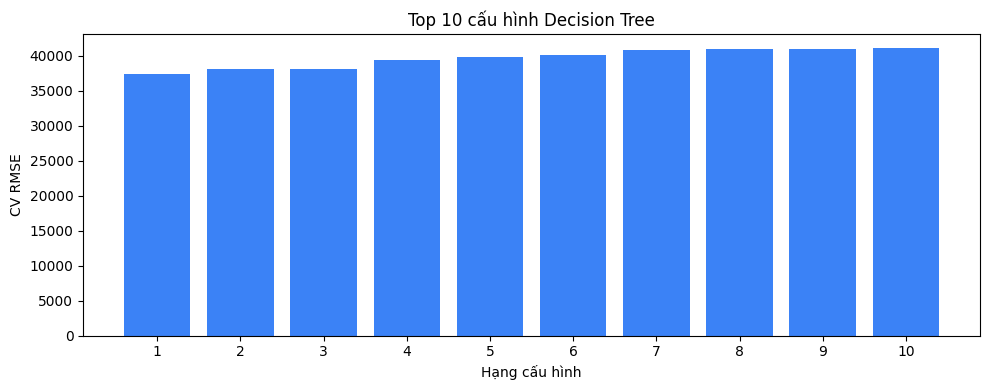

In [10]:
results_df = pd.DataFrame(search.cv_results_)
results_df["rmse"] = np.sqrt(-results_df["mean_test_score"])
results_df["rmse_std"] = np.sqrt(results_df["std_test_score"].clip(lower=0))

top10 = results_df.sort_values("rmse").head(10)[
    [
        "rmse",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "param_max_features",
        "param_criterion",
    ]
].reset_index(drop=True)

print("=== TOP 10 CẤU HÌNH TỐT NHẤT ===")
display(top10) if "display" in dir() else print(top10.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, len(top10) + 1), top10["rmse"], color="#3b82f6")
ax.set_xlabel("Hạng cấu hình")
ax.set_ylabel("CV RMSE")
ax.set_title("Top 10 cấu hình Decision Tree")
ax.set_xticks(range(1, len(top10) + 1))
plt.tight_layout()
plt.show()

## 7. Feature importance

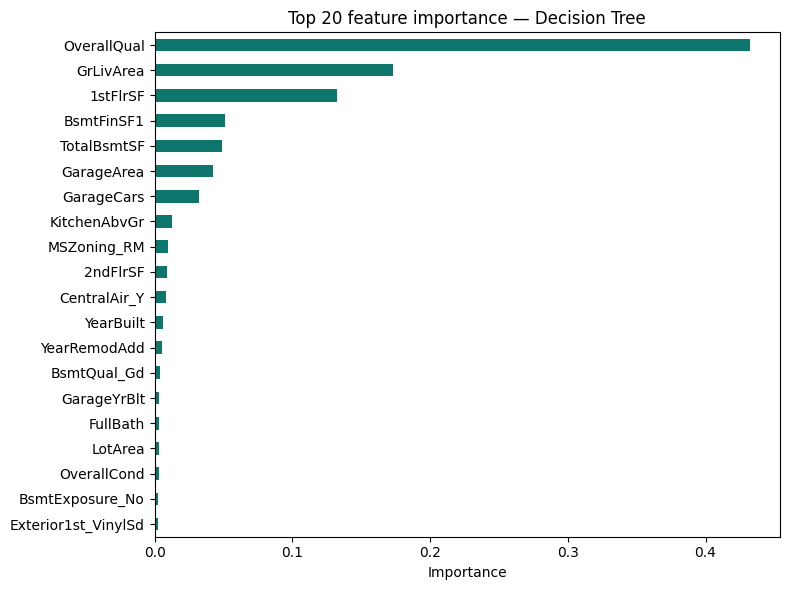

OverallQual            0.432476
GrLivArea              0.172764
1stFlrSF               0.132662
BsmtFinSF1             0.051053
TotalBsmtSF            0.049149
GarageArea             0.042505
GarageCars             0.032095
KitchenAbvGr           0.012688
MSZoning_RM            0.009310
2ndFlrSF               0.008972
CentralAir_Y           0.008353
YearBuilt              0.006075
YearRemodAdd           0.005203
BsmtQual_Gd            0.003626
GarageYrBlt            0.003156
FullBath               0.003126
LotArea                0.003003
OverallCond            0.002760
BsmtExposure_No        0.002459
Exterior1st_VinylSd    0.002312
dtype: float64


In [11]:
best_model = search.best_estimator_
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top_feat = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top_feat.sort_values().plot(kind="barh", ax=ax, color="#0f766e")
ax.set_title("Top 20 feature importance — Decision Tree")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print(top_feat)

## 8. Predict test set

In [12]:
preds = best_model.predict(X_test)
print("Predictions:", preds.shape, "| min/mean/max:", preds.min(), preds.mean(), preds.max())

Predictions: (1459,) | min/mean/max: 61000.0 178630.30603152845 555000.0


## 9. Lưu experiments/decision_tree/<timestamp>/

Mỗi lần chạy cell này tạo **folder mới** theo thời gian, không ghi đè lần cũ.

In [13]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = Path("experiments") / "decision_tree" / timestamp
run_dir.mkdir(parents=True, exist_ok=True)
print("Đang lưu vào:", run_dir.resolve())

config = {
    "model_name": "decision_tree",
    "best_params": search.best_params_,
    "n_iter": 30,
    "cv": 5,
    "scoring": "neg_mean_squared_error",
    "random_state": 42,
    "n_features": int(X.shape[1]),
    "timestamp": timestamp,
}
with open(run_dir / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False, default=str)

metrics = {
    "best_cv_rmse": best_cv_rmse,
    "baseline_cv_rmse": baseline_rmse,
    "improvement": float(baseline_rmse - best_cv_rmse),
    "n_iter": 30,
    "cv_folds": 5,
}
with open(run_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

joblib.dump(best_model, run_dir / "model.pkl")

sub = sample_sub.copy()
sub["SalePrice"] = preds
sub.to_csv(run_dir / "predictions.csv", index=False)

top10.to_csv(run_dir / "top10_configs.csv", index=False)

# file nộp Kaggle (cùng thư mục làm việc)
sub.to_csv("submission_decision_tree.csv", index=False)

print("\nĐã lưu:")
for f in sorted(run_dir.iterdir()):
    print(" -", f.name, f"({f.stat().st_size} bytes)")
print("\nFile nộp Kaggle: submission_decision_tree.csv")

Đang lưu vào: /content/drive/MyDrive/Lab02_HousePrice/experiments/decision_tree/20260920_235559

Đã lưu:
 - config.json (338 bytes)
 - metrics.json (150 bytes)
 - model.pkl (17745 bytes)
 - predictions.csv (20353 bytes)
 - top10_configs.csv (532 bytes)

File nộp Kaggle: submission_decision_tree.csv


## 10. So sánh các lần chạy (nếu đã chạy nhiều lần)

In [14]:
exp_dir = Path("experiments") / "decision_tree"
print("=== So sánh RMSE các lần chạy Decision Tree ===")
if not exp_dir.exists():
    print("Chưa có folder experiments/decision_tree")
else:
    rows = []
    for folder in sorted(exp_dir.iterdir()):
        metrics_file = folder / "metrics.json"
        if folder.is_dir() and metrics_file.exists():
            with open(metrics_file, encoding="utf-8") as f:
                m = json.load(f)
            rows.append({
                "folder": folder.name,
                "best_cv_rmse": m.get("best_cv_rmse"),
                "baseline_cv_rmse": m.get("baseline_cv_rmse"),
            })
            print(f"{folder.name}  →  RMSE = {m.get('best_cv_rmse')}")
    if rows:
        cmp_df = pd.DataFrame(rows).sort_values("best_cv_rmse")
        print("\nFolder tốt nhất:", cmp_df.iloc[0]["folder"])

=== So sánh RMSE các lần chạy Decision Tree ===
20260920_235559  →  RMSE = 37491.76064824978

Folder tốt nhất: 20260920_235559
